# Evaluation of Translation Models

## 1 Overview

## 2 Importing Libraries

In [1]:
# importing libraries
import gc
import random
import time

from pathlib import Path

import pandas as pd
import torch

from datasets import load_dataset
from sacrebleu.metrics import BLEU, CHRF
from transformers import (
    AutoModelForSeq2SeqLM,
    AutoProcessor,
    AutoTokenizer,
    M2M100ForConditionalGeneration,
    M2M100Tokenizer,
    SeamlessM4TForTextToText
)

c:\Users\Subathra\OneDrive\Desktop\cm3020_Final_Year_project\CM3020_Final_Year_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3 Evaluation Settings and Candidate Models

In [2]:
# result reproducible
SEED = 42

random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
# use gpu when it is available
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

dtype = (
    torch.float16
    if torch.cuda.is_available()
    else torch.float32
)

print("Device:", device)

Device: cuda


In [4]:
# evaluation sizes
VALIDATION_SIZE = 100
TEST_SIZE = 100

In [5]:
# output folder to store results
output_folder = Path("outputs/translation")
output_folder.mkdir(parents=True, exist_ok=True)

In [6]:
# Candidate translation models
models = {
    "NLLB-200": {
        "model_id": "facebook/nllb-200-distilled-600M",
        "batch_size": 8
    },

    "M2M100": {
        "model_id": "facebook/m2m100_418M",
        "batch_size": 8
    },

    "SeamlessM4T": {
        "model_id": "facebook/hf-seamless-m4t-medium",
        "batch_size": 2
    }
}

In [7]:
# target languages
languages = ["Malay", "Chinese", "Tamil"]

In [8]:
print("Models:", len(models))
print("Languages:", languages)

Models: 3
Languages: ['Malay', 'Chinese', 'Tamil']


In [9]:
model_information = []

for model_name, details in models.items():
    model_information.append({
        "Model": model_name,
        "Model ID": details["model_id"]
    })

model_information_df = pd.DataFrame(model_information)
model_information_df

,Model,Model ID
0,NLLB-200,facebook/nllb-200-distilled-600M
1,M2M100,facebook/m2m100_418M
2,SeamlessM4T,facebook/hf-seamless-m4t-medium


## 4 Load Processed OPUS-100 Evaluation Data

In [10]:
# load cleaned OPUS-100 evaluation data
processed_folder = Path(
    "../../data/processed/opus100_translation"
)

validation_folder = (
    processed_folder
    / "validation"
)

testing_folder = (
    processed_folder
    / "testing"
)

validation_data = {}
testing_data = {}

for language in languages:

    filename = (
        language.lower()
        + ".csv"
    )

    validation_df = pd.read_csv(
        validation_folder
        / filename
    )

    testing_df = pd.read_csv(
        testing_folder
        / filename
    )

    validation_data[language] = {
        "source":
            validation_df[
                "source"
            ].tolist(),

        "reference":
            validation_df[
                "reference"
            ].tolist()
    }

    testing_data[language] = {
        "source":
            testing_df[
                "source"
            ].tolist(),

        "reference":
            testing_df[
                "reference"
            ].tolist()
    }

print(
    "Clean OPUS-100 evaluation data loaded."
)

Clean OPUS-100 evaluation data loaded.


In [11]:
for language in languages:

    assert (
        len(
            validation_data[
                language
            ]["source"]
        )
        == VALIDATION_SIZE
    )

    assert (
        len(
            testing_data[
                language
            ]["source"]
        )
        == TEST_SIZE
    )

print(
    "All translation evaluation "
    "samples loaded correctly."
)

All translation evaluation samples loaded correctly.


In [12]:
print("Validation samples")

for language in languages:
    print(
        language,
        len(validation_data[language]["source"])
    )

print("\nTest samples")

for language in languages:
    print(
        language,
        len(testing_data[language]["source"])
    )

Validation samples
Malay 100
Chinese 100
Tamil 100

Test samples
Malay 100
Chinese 100
Tamil 100


In [13]:
for language in languages:
    print(f"\n{language}")
    print(
        "English:",
        validation_data[language]["source"][0]
    )
    print(
        "Reference:",
        validation_data[language]["reference"][0]
    )


Malay
English: You have killed his enemy... and his suspicions.
Reference: Awak telah membunuh musuh dia... dan juga perasaan syak wasangkanya.

Chinese
English: These efforts were duly reflected in Guatemala's participation in the Commission on Human Rights, and we pledge to sustain them in the future work of the Human Rights Council.
Reference: 这些努力正确反映于危地马拉参加人权委员会，我们保证将来在人权理事会继续这样努力。

Tamil
English: Fix stair-stepping text
Reference: படிக்கட்டான உரையைச் சரிசெய்


## 5 Language Code Alignment

In [14]:
# language codes used by each model
language_codes = {
    "Malay": {
        "NLLB-200": "zsm_Latn",
        "M2M100": "ms",
        "SeamlessM4T": "zsm"
    },

    "Chinese": {
        "NLLB-200": "zho_Hans",
        "M2M100": "zh",
        "SeamlessM4T": "cmn"
    },

    "Tamil": {
        "NLLB-200": "tam_Taml",
        "M2M100": "ta",
        "SeamlessM4T": "tam"
    }
}

## 6 Evaluation Method

In [15]:
bleu_metric = BLEU()

chrf_metric = CHRF(
    word_order=2
)


def calculate_translation_metrics(
    predictions,
    references
):
    bleu_score = bleu_metric.corpus_score(
        predictions,
        [references]
    ).score

    chrf_score = chrf_metric.corpus_score(
        predictions,
        [references]
    ).score

    return chrf_score, bleu_score

In [16]:
def create_batches(data, batch_size):
    for start in range(0, len(data), batch_size):
        yield data[start:start + batch_size]

In [17]:
def evaluate_predictions(
    model_name,
    predictions,
    data,
    inference_time
):
    results = []

    for language in languages:

        chrf_score, bleu_score = (
            calculate_translation_metrics(
                predictions[language],
                data[language]["reference"]
            )
        )

        sample_count = len(
            data[language]["source"]
        )

        results.append({
            "model": model_name,
            "language": language,
            "chrF++": chrf_score,
            "BLEU": bleu_score,
            "inference_time":
                inference_time[language],
            "ms_per_sentence":
                inference_time[language]
                / sample_count
                * 1000
        })

    return pd.DataFrame(results)

## 7 Evaluating Candidate Models on Validation Data

In [18]:
def evaluate_nllb(data):
    model_id = models["NLLB-200"]["model_id"]
    batch_size = models["NLLB-200"]["batch_size"]

    start = time.perf_counter()

    tokenizer = AutoTokenizer.from_pretrained(
        model_id,
        src_lang="eng_Latn"
    )

    model = AutoModelForSeq2SeqLM.from_pretrained(
        model_id,
        dtype=dtype
    ).to(device)

    model.eval()

    loading_time = time.perf_counter() - start

    predictions = {}
    inference_times = {}

    for language in languages:
        translated = []

        start = time.perf_counter()

        target_id = tokenizer.convert_tokens_to_ids(
            language_codes[language]["NLLB-200"]
        )

        for batch in create_batches(
            data[language]["source"],
            batch_size
        ):
            inputs = tokenizer(
                batch,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=256
            ).to(device)

            with torch.inference_mode():
                outputs = model.generate(
                    **inputs,
                    forced_bos_token_id=target_id,
                    max_new_tokens=256
                )

            translated.extend(
                tokenizer.batch_decode(
                    outputs,
                    skip_special_tokens=True
                )
            )

        inference_times[language] = time.perf_counter() - start
        predictions[language] = translated

    del model, tokenizer
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    results = evaluate_predictions(
        "NLLB-200",
        predictions,
        data,
        inference_times
    )

    return results, loading_time, predictions

In [19]:
print("Evaluating NLLB-200...")

nllb_results, nllb_loading_time, nllb_predictions = evaluate_nllb(
    validation_data
)

nllb_results

Evaluating NLLB-200...


,model,language,chrF++,BLEU,inference_time,ms_per_sentence
0,NLLB-200,Malay,44.586308,20.495425,2.910527,29.105270
1,NLLB-200,Chinese,23.444450,1.536020,9.629896,96.298958
2,NLLB-200,Tamil,32.494455,7.265153,6.911925,69.119252


In [20]:
def evaluate_m2m100(data):
    model_id = models["M2M100"]["model_id"]
    batch_size = models["M2M100"]["batch_size"]

    start = time.perf_counter()

    tokenizer = M2M100Tokenizer.from_pretrained(model_id)

    model = M2M100ForConditionalGeneration.from_pretrained(
        model_id,
        dtype=dtype
    ).to(device)

    model.eval()

    loading_time = time.perf_counter() - start

    predictions = {}
    inference_times = {}

    for language in languages:
        translated = []

        tokenizer.src_lang = "en"

        target_id = tokenizer.get_lang_id(
            language_codes[language]["M2M100"]
        )

        start = time.perf_counter()

        for batch in create_batches(
            data[language]["source"],
            batch_size
        ):
            inputs = tokenizer(
                batch,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=256
            ).to(device)

            with torch.inference_mode():
                outputs = model.generate(
                    **inputs,
                    forced_bos_token_id=target_id,
                    max_new_tokens=256
                )

            translated.extend(
                tokenizer.batch_decode(
                    outputs,
                    skip_special_tokens=True
                )
            )

        inference_times[language] = time.perf_counter() - start
        predictions[language] = translated

    del model, tokenizer
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    results = evaluate_predictions(
        "M2M100",
        predictions,
        data,
        inference_times
    )

    return results, loading_time, predictions

In [21]:
print("Evaluating M2M100...")

m2m100_results, m2m100_loading_time, m2m100_predictions = evaluate_m2m100(
    validation_data
)

m2m100_results

Evaluating M2M100...


,model,language,chrF++,BLEU,inference_time,ms_per_sentence
0,M2M100,Malay,41.461603,13.809101,3.422684,34.226845
1,M2M100,Chinese,22.257584,2.112001,12.872314,128.723137
2,M2M100,Tamil,22.651929,8.060256,6.936840,69.368398


In [22]:
def evaluate_seamless(data):
    model_id = models["SeamlessM4T"]["model_id"]
    batch_size = models["SeamlessM4T"]["batch_size"]

    start = time.perf_counter()

    processor = AutoProcessor.from_pretrained(model_id)

    model = SeamlessM4TForTextToText.from_pretrained(
        model_id,
        dtype=dtype
    ).to(device)

    model.eval()

    loading_time = time.perf_counter() - start

    predictions = {}
    inference_times = {}

    for language in languages:
        translated = []

        start = time.perf_counter()

        for batch in create_batches(
            data[language]["source"],
            batch_size
        ):
            inputs = processor(
                text=batch,
                src_lang="eng",
                return_tensors="pt",
                padding=True
            ).to(device)

            with torch.inference_mode():
                outputs = model.generate(
                    **inputs,
                    tgt_lang=language_codes[language]["SeamlessM4T"],
                    max_new_tokens=256
                )

            translated.extend(
                processor.batch_decode(
                    outputs,
                    skip_special_tokens=True
                )
            )

        inference_times[language] = time.perf_counter() - start
        predictions[language] = translated

    del model, processor
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    results = evaluate_predictions(
        "SeamlessM4T",
        predictions,
        data,
        inference_times
    )

    return results, loading_time, predictions

In [23]:
print("Evaluating SeamlessM4T...")

seamless_results, seamless_loading_time, seamless_predictions = evaluate_seamless(
    validation_data
)

seamless_results

Evaluating SeamlessM4T...


,model,language,chrF++,BLEU,inference_time,ms_per_sentence
0,SeamlessM4T,Malay,41.939512,17.920507,7.628346,76.283459
1,SeamlessM4T,Chinese,20.274557,0.991494,21.308962,213.089622
2,SeamlessM4T,Tamil,28.240007,6.620522,10.944785,109.447848


In [24]:
validation_results_df = pd.concat(
    [
        nllb_results,
        m2m100_results,
        seamless_results
    ],
    ignore_index=True
)

In [25]:
validation_results_df

,model,language,chrF++,BLEU,inference_time,ms_per_sentence
0,NLLB-200,Malay,44.586308,20.495425,2.910527,29.105270
1,NLLB-200,Chinese,23.444450,1.536020,9.629896,96.298958
2,NLLB-200,Tamil,32.494455,7.265153,6.911925,69.119252
3,M2M100,Malay,41.461603,13.809101,3.422684,34.226845
4,M2M100,Chinese,22.257584,2.112001,12.872314,128.723137
5,M2M100,Tamil,22.651929,8.060256,6.936840,69.368398
6,SeamlessM4T,Malay,41.939512,17.920507,7.628346,76.283459
7,SeamlessM4T,Chinese,20.274557,0.991494,21.308962,213.089622
8,SeamlessM4T,Tamil,28.240007,6.620522,10.944785,109.447848


## 8 Comparing and Selecting the Best Model

In [26]:
loading_times = {
    "NLLB-200": nllb_loading_time,
    "M2M100": m2m100_loading_time,
    "SeamlessM4T": seamless_loading_time
}

In [27]:
comparison_results = []

for model_name in models:
    results = validation_results_df[
        validation_results_df["model"] == model_name
    ]

    comparison_results.append({
        "Model": model_name,
        "Average chrF++":
            results["chrF++"].mean(),

        "Average BLEU":
            results["BLEU"].mean(),

        "Loading Time":
            loading_times[model_name],

        "Inference Time":
            results["inference_time"].sum(),

        "ms / sentence":
            results["ms_per_sentence"].mean()
    })

comparison_df = pd.DataFrame(
    comparison_results
)

In [28]:
comparison_df = comparison_df.sort_values(
    [
        "Average chrF++",
        "Average BLEU",
        "Inference Time"
    ],
    ascending=[
        False,
        False,
        True
    ]
).reset_index(drop=True)

comparison_df

,Model,Average chrF++,Average BLEU,Loading Time,Inference Time,ms / sentence
0,NLLB-200,33.508404,9.765533,7.833593,19.452348,64.84116
1,SeamlessM4T,30.151359,8.510841,12.941571,39.882093,132.94031
2,M2M100,28.790372,7.993786,4.976039,23.231838,77.43946


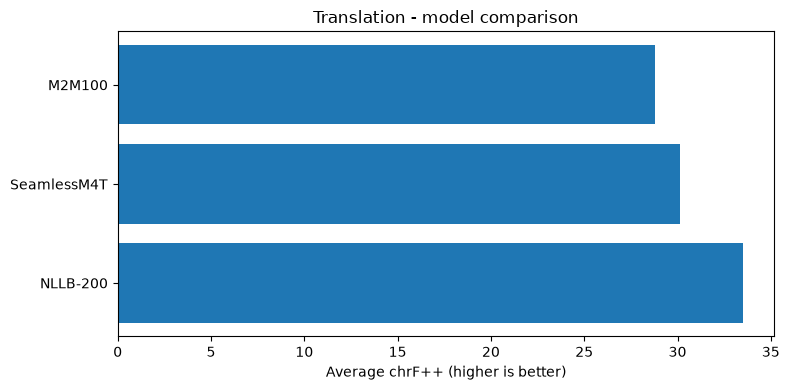

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.barh(
    comparison_df["Model"],
    comparison_df["Average chrF++"]
)

plt.xlabel(
    "Average chrF++ (higher is better)"
)

plt.title(
    "Translation - model comparison"
)

plt.tight_layout()

plt.show()

In [30]:
selected_model_name = comparison_df.loc[
    0,
    "Model"
]

print(
    "Selected model:",
    selected_model_name
)

print(
    "Model ID:",
    models[selected_model_name]["model_id"]
)

Selected model: NLLB-200
Model ID: facebook/nllb-200-distilled-600M


## 9 Final Test Evaluation

In [31]:
if selected_model_name == "NLLB-200":
    test_results_df, test_loading_time, test_predictions = evaluate_nllb(
        testing_data
    )

elif selected_model_name == "M2M100":
    test_results_df, test_loading_time, test_predictions = evaluate_m2m100(
        testing_data
    )

else:
    test_results_df, test_loading_time, test_predictions = evaluate_seamless(
        testing_data
    )

In [32]:
test_summary_df = pd.DataFrame([
    {
        "Selected Model":
            selected_model_name,

        "Average chrF++":
            test_results_df[
                "chrF++"
            ].mean(),

        "Average BLEU":
            test_results_df[
                "BLEU"
            ].mean(),

        "Loading Time":
            test_loading_time,

        "Inference Time":
            test_results_df[
                "inference_time"
            ].sum(),

        "ms / sentence":
            test_results_df[
                "ms_per_sentence"
            ].mean()
    }
])

## 10 Translation Examples

In [33]:
translation_examples = []

for language in languages:
    for index in range(5):
        translation_examples.append({
            "Language": language,
            "English":
                testing_data[language]["source"][index],
            "Reference":
                testing_data[language]["reference"][index],
            "Prediction":
                test_predictions[language][index]
        })

translation_examples_df = pd.DataFrame(
    translation_examples
)

translation_examples_df

,Language,English,Reference,Prediction
0,Malay,"We appreciate the effort, but the point was no...","Kami menghargai usaha, tetapi titik itu bukan ...","Kami menghargai usaha itu, tetapi intinya buka..."
1,Malay,So he let us go,Jadi dia biarkan kita pergi.,Jadi dia membiarkan kita pergi
2,Malay,And they persisted in rejecting them wrongfull...,Dan mereka mengingkarinya secara zalim dan som...,Dan mereka tetap mendustakannya dengan tidak b...
3,Malay,Drive home from Trenton.,Pulang dari Trenton.,Memandu pulang dari Trenton.
4,Malay,"Now, SpongeBob loved his job as a fry cook mor...",SpongeBob amat menyayangi pekerjaannya sebagai...,"Sekarang, SpongeBob suka pekerjaannya sebagai ..."
5,Chinese,The documents used by the Advisory Committee i...,2. 咨询委员会审议ONUB经费的筹措时使用的文件列在本报告末尾。,咨询委员会在审议ONUB资金时使用的文件列出了本报告的最后.
6,Chinese,"After that, you could forget about Evel Knievel.","在那之后, 你都可以忘了埃维尔·克尼维尔.","之后,你可能会忘记埃维尔·克尼维尔."
7,Chinese,"Secondly, it is necessary for the inspection w...",二． 对伊拉克的核查工作有必要继续进行下去。,"第二,伊拉克的检查工作必须继续."
8,Chinese,...and then I start.,...我開始了,然后我开始.
9,Chinese,This is quite definitely real turtle soup.,这是十分明显的，真正的甲鱼汤,这绝对是真正的鱼.


## 11 Saving Evaluation Results

In [34]:
validation_results_df.to_csv(
    output_folder
    / "translation_validation_results.csv",
    index=False
)

comparison_df.to_csv(
    output_folder
    / "translation_model_comparison.csv",
    index=False
)

test_results_df.to_csv(
    output_folder
    / "selected_translation_model_test_results.csv",
    index=False
)

test_summary_df.to_csv(
    output_folder
    / "selected_translation_model_test_summary.csv",
    index=False
)

translation_examples_df.to_csv(
    output_folder
    / "translation_examples.csv",
    index=False
)

print(
    "Results saved in:",
    output_folder
)

Results saved in: outputs\translation


## 12 Conclusion